In [1]:
from pathlib import Path
from typing import Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import edgepython as ep
import gseapy as gp
from XvP_utils import plotting
import re

%matplotlib inline

# (label, analysis_name, 10x_assay, parse_assay, tissue)
SAMPLES = [
    ("A3_H1", "Analysis_3", "10x_H1",  "parse_H1",  "PBMC"),
    ("A3_H2", "Analysis_3", "10x_H2",  "parse_H2",  "PBMC"),
    ("A5",    "Analysis_5", "10x",      "parse",      "Frozen PBMC"),
    #("A6",    "Analysis_6", "10x",      "parse",      "Cancer"),
    ("A7",    "Analysis_7", "10x",      "parse",      "Frozen PBMC"),
]

COMPARING=("10x", "parse")
FDR=0.01
PROJECT_DIR = Path("/home/mcaskey/10XvParse/")

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
combined = plotting.load_cross_comparison_data(SAMPLES, comparison=COMPARING, project_dir=PROJECT_DIR)

Loading A3_H1...
Loading A3_H2...
Loading A5...
Loading A7...

21523 genes retained across all 10 samples


TMM norm factors: [0.8639 0.8791 0.981  0.9041 1.1057 1.1107 1.1486 1.0524]
Design: 8 samples x 3 coefficients  (df.residual = 5)
Retained 20826 / 21523 genes after filterByExpr
Common dispersion (BCV): 0.4812


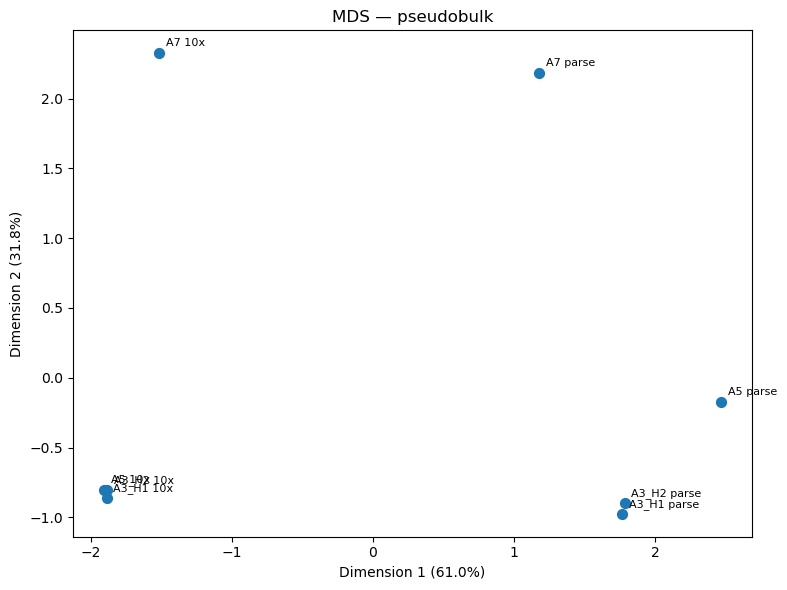

In [4]:
dge_f, fit, qlf, design, results = plotting.perform_edgepy(combined, COMPARING, SAMPLES)

labels      = [s[0] for s in SAMPLES]
col_labels  = [f"{l} {COMPARING[0]}" for l in labels] + [f"{l} {COMPARING[1]}" for l in labels]

# MDS plot
ep.plot_mds(dge_f, labels=col_labels, main="MDS — pseudobulk")
plt.show()

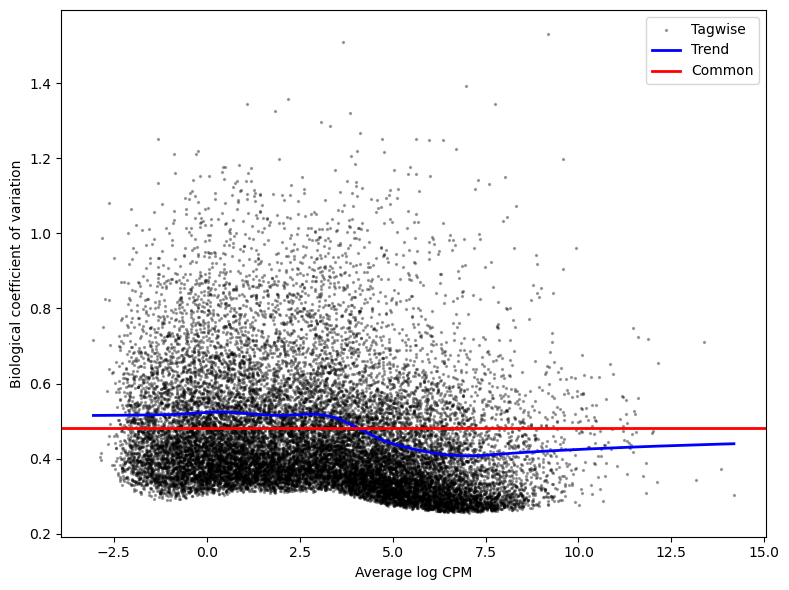

In [5]:
ep.plot_bcv(dge_f, main="BCV plot")
plt.show()

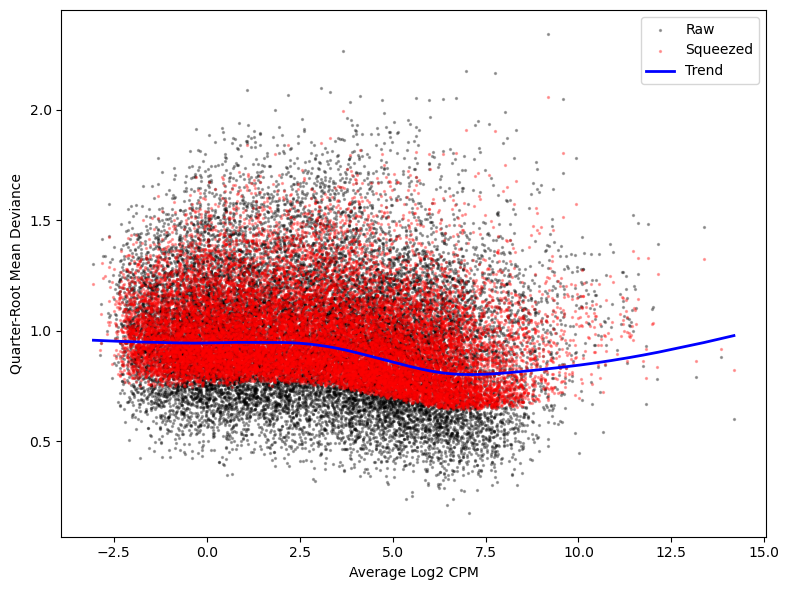

In [6]:
ep.plot_ql_disp(fit, main="QL dispersion")
plt.show()

In [7]:
# Merge gene annotations
attrs = pd.read_csv(
    PROJECT_DIR / "Notebooks/Analysis_5/gene_data/gene_attributes.csv",
    usecols=["gene_name", "gene_length", "gc_content",
             "is_lnc", "is_pc", "is_mito", "is_ribo"],
)
results = results.merge(attrs, on="gene_name", how="left")

# Print number of signifant genes for eachs side
n1   = ((results["FDR"] < FDR) & (results["logFC"] < 0)).sum()
n2 = ((results["FDR"] < FDR) & (results["logFC"] > 0)).sum()
print(f"FDR < {FDR}:  {n1} genes higher in {COMPARING[0]},  {n2} genes higher in {COMPARING[1]}")

FDR < 0.01:  2407 genes higher in 10x,  1264 genes higher in parse


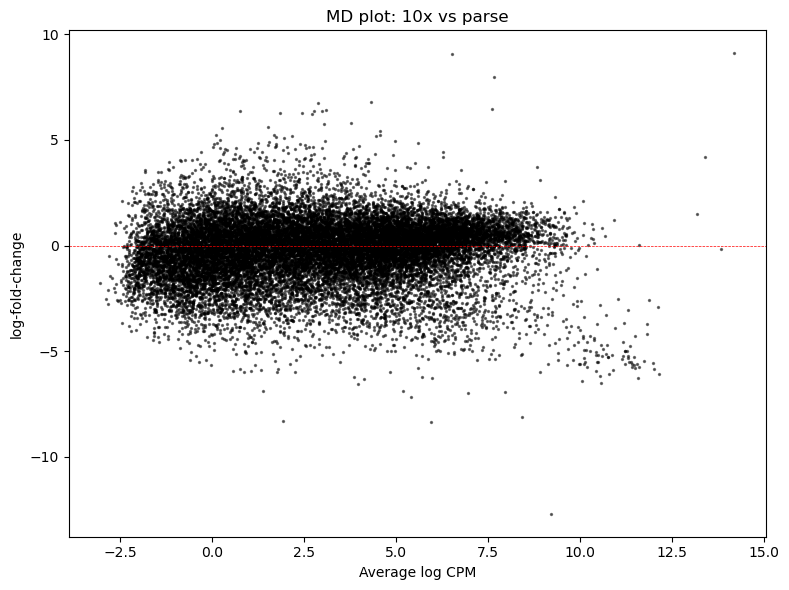

In [8]:
# MD plot
ep.plot_md(qlf, main=f"MD plot: {COMPARING[0]} vs {COMPARING[1]}")
plt.show()

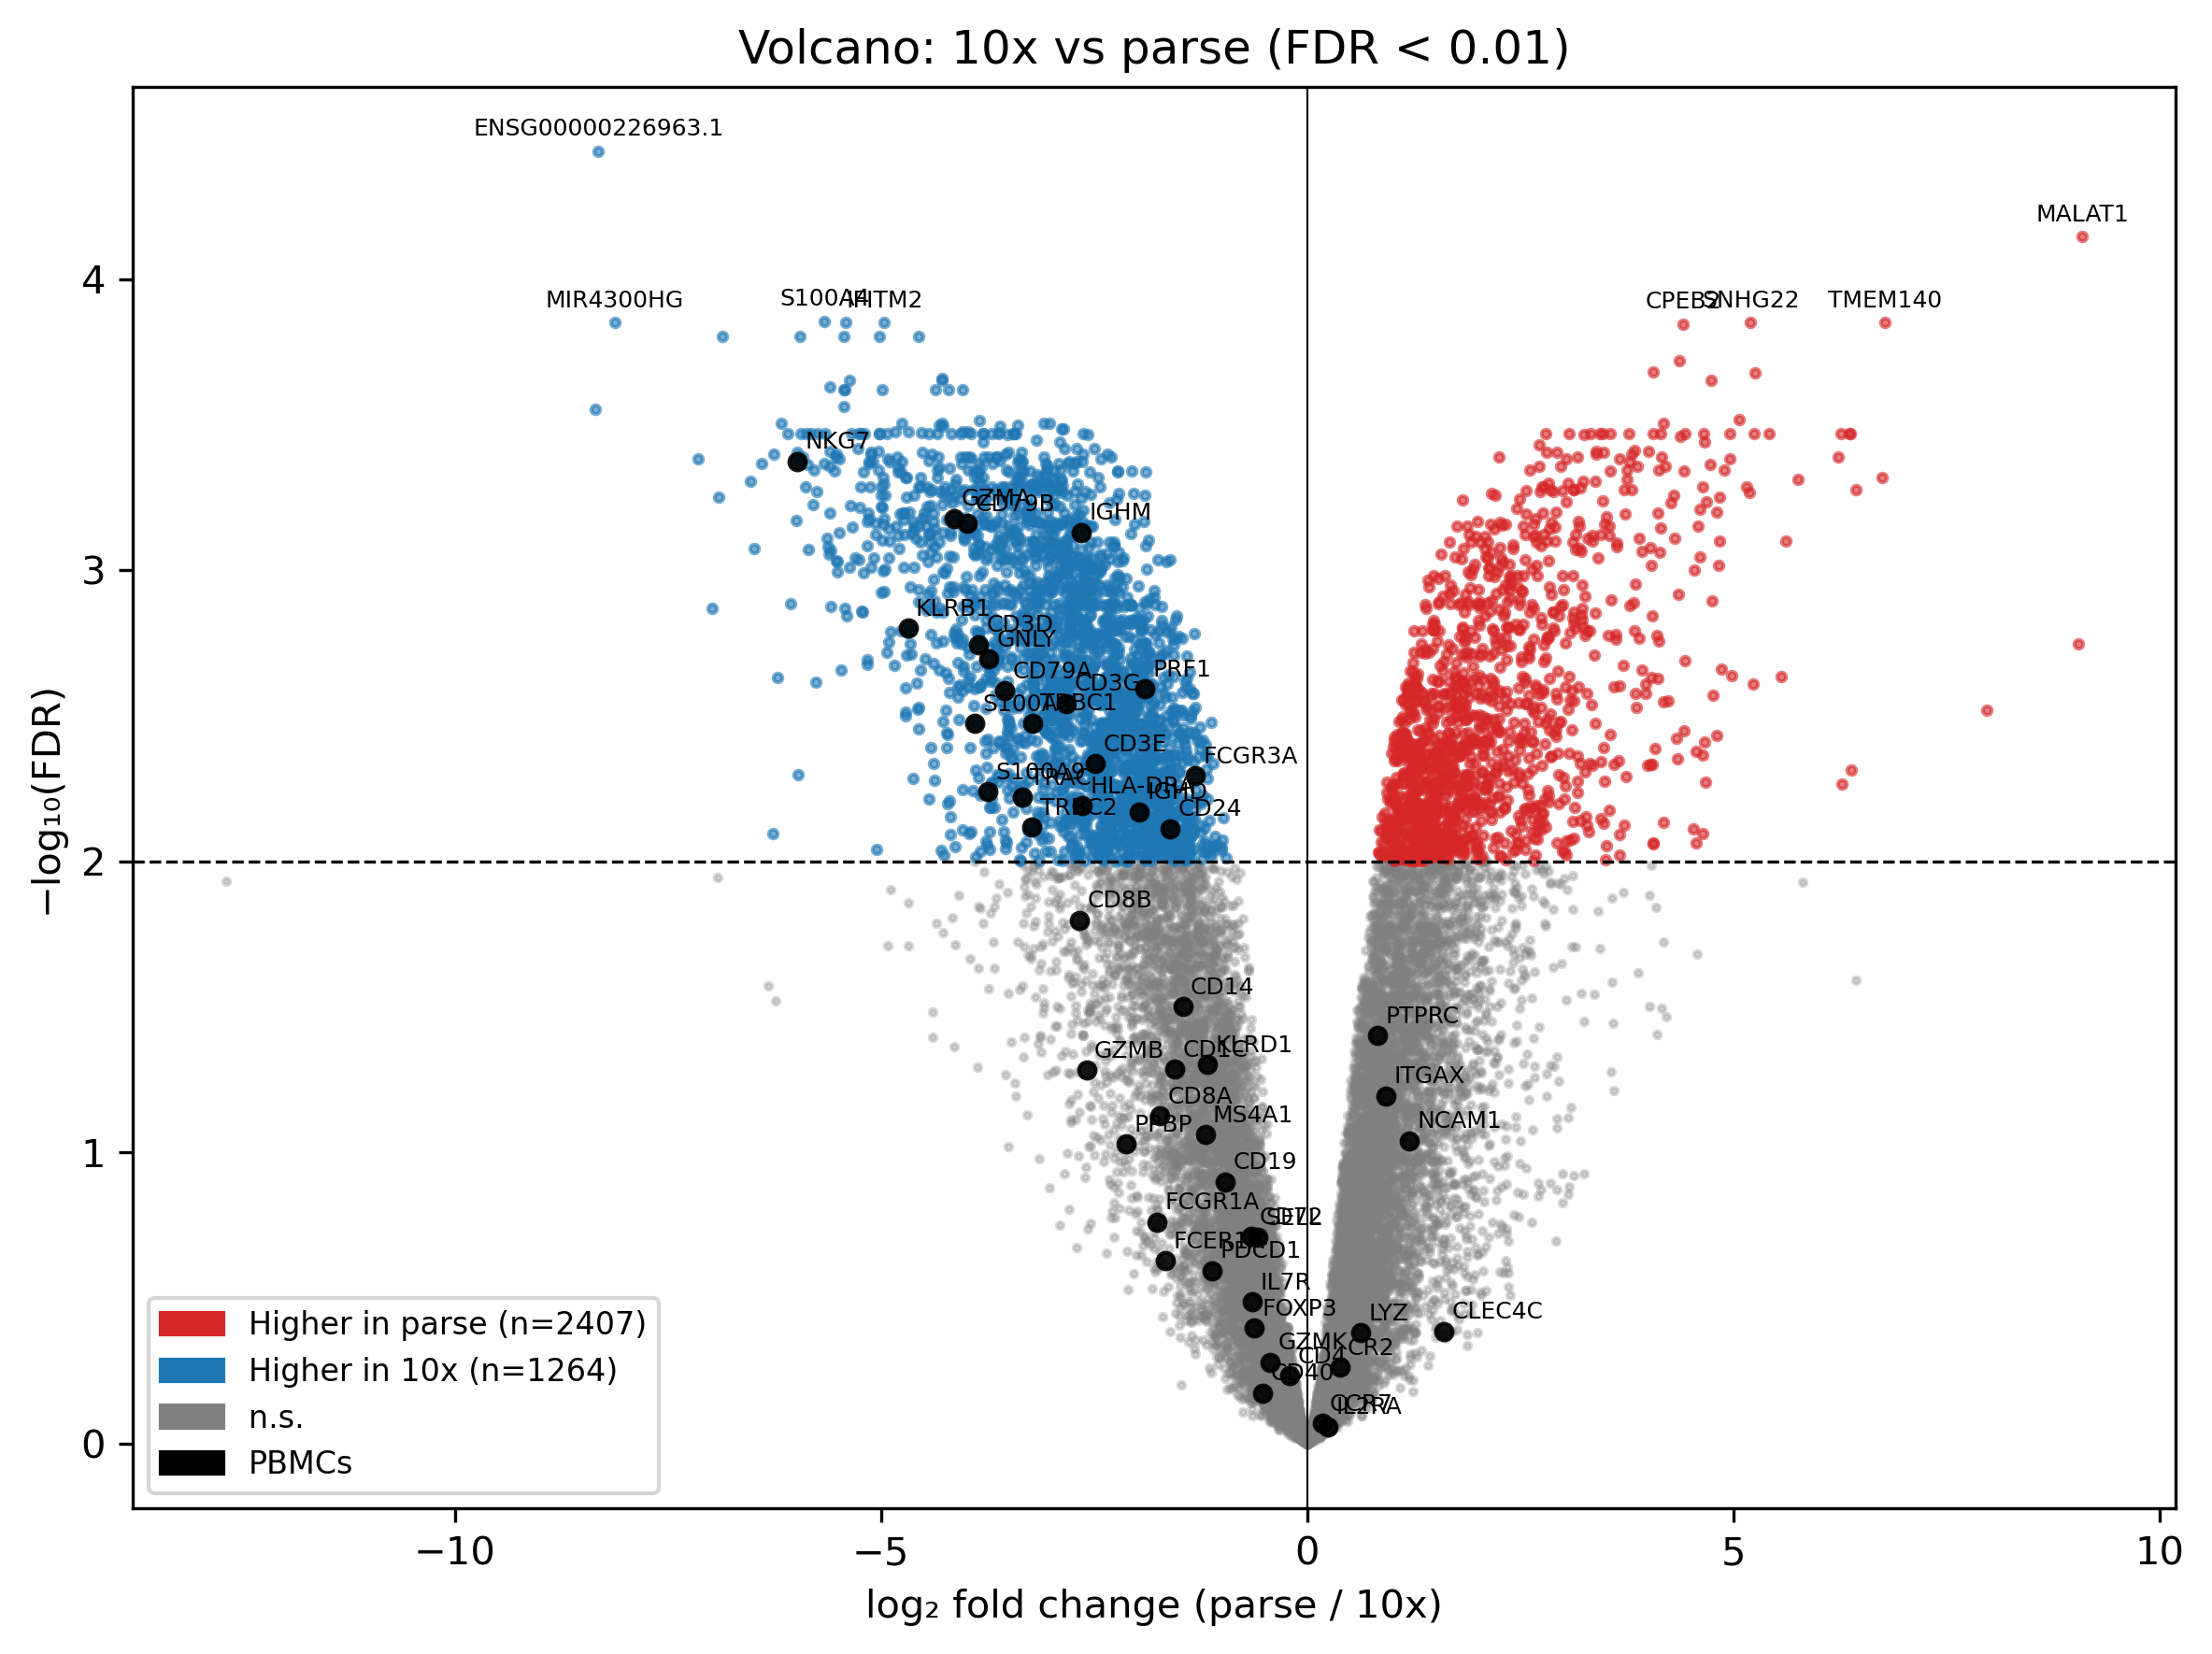

In [16]:
plotting.volcano_plot(results, 
                      COMPARING, 
                      FDR, 
                      label_num = 4,
                      marker_genes_path="/home/mcaskey/10XvParse/Notebooks/important_gene_sets.csv",
                      gene_sets=["Tissue Marker"],
                      terms=["PBMCs"],
                      )

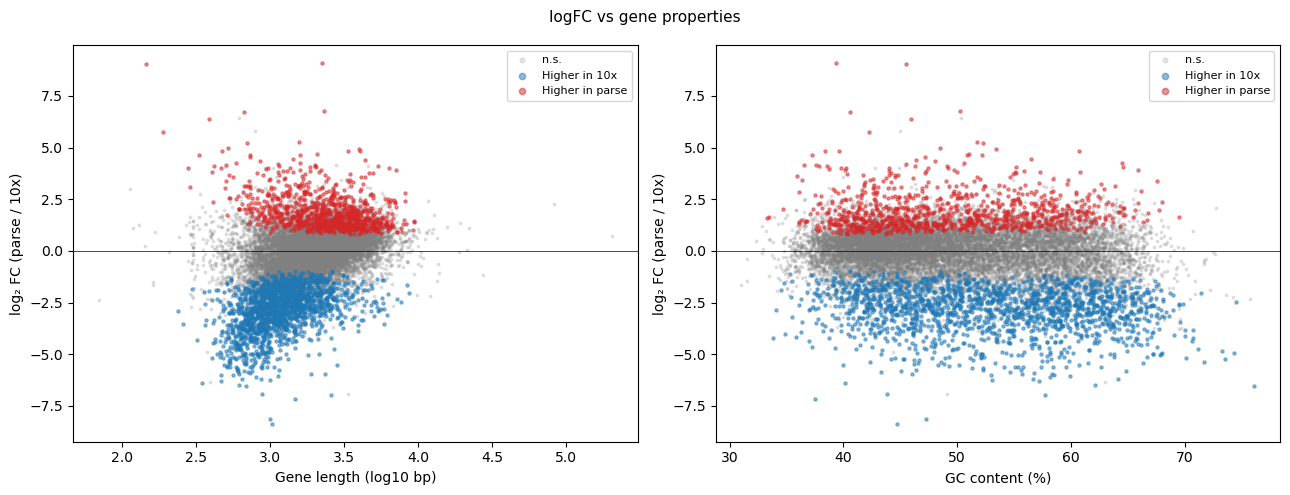

In [10]:
plotting.plot_differential_metrics(results, COMPARING, FDR)

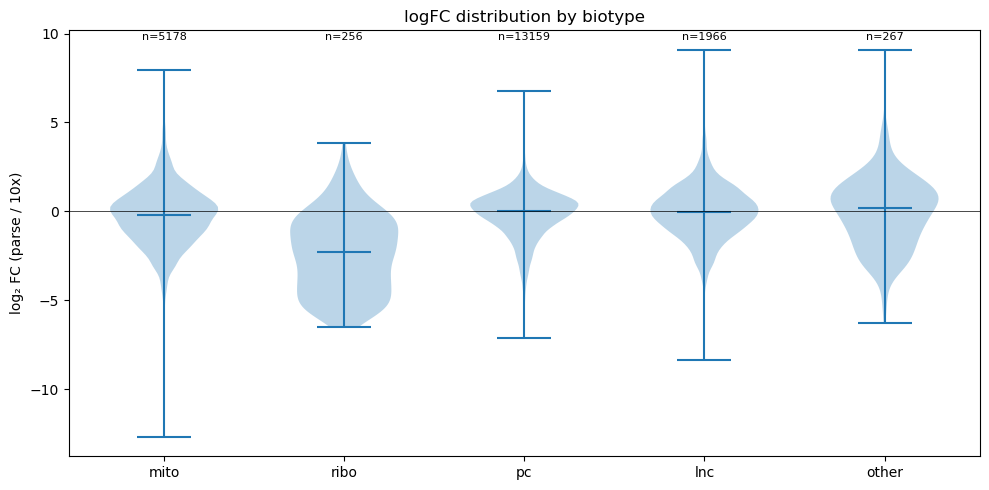

In [11]:
plotting.plot_differential_biotype(results, COMPARING)

In [12]:
sig_10x   = results.loc[(results["FDR"] < 0.01) & (results["logFC"] < 0), "gene_name"].tolist()
sig_parse = results.loc[(results["FDR"] < 0.01) & (results["logFC"] > 0), "gene_name"].tolist()

/home/mcaskey/10XvParse/XvP_utils/plotting/cross_comparison.py:249: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(n_per_db, 'nlp'))
/home/mcaskey/10XvParse/XvP_utils/plotting/cross_comparison.py:249: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(n_per_db, 'nlp'))


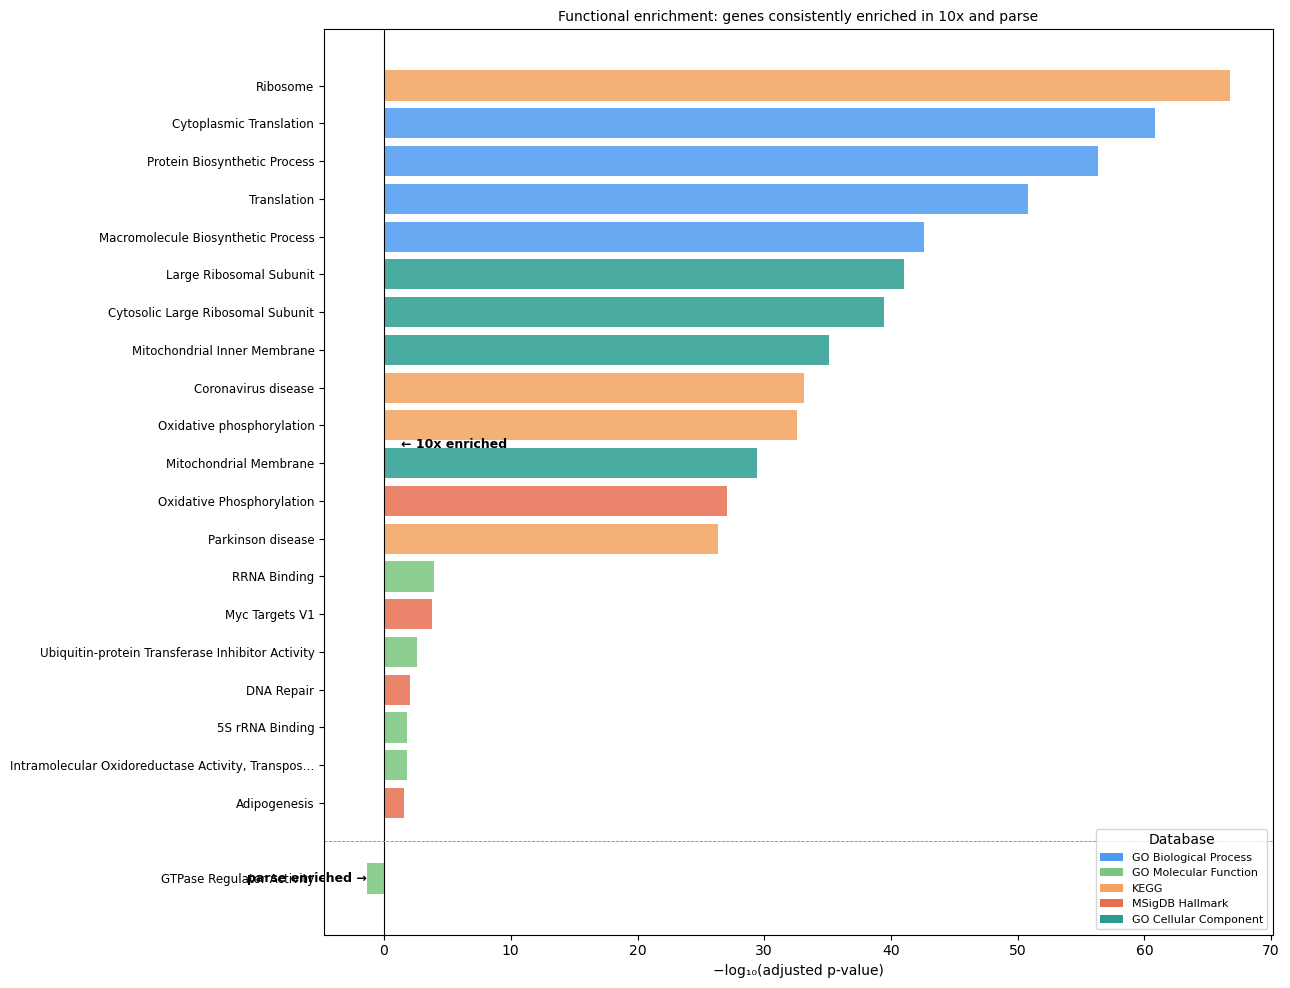

In [13]:
plotting.enrichment_analysis(combined=combined, results=results, comparing=COMPARING, fdr_thresh=FDR)

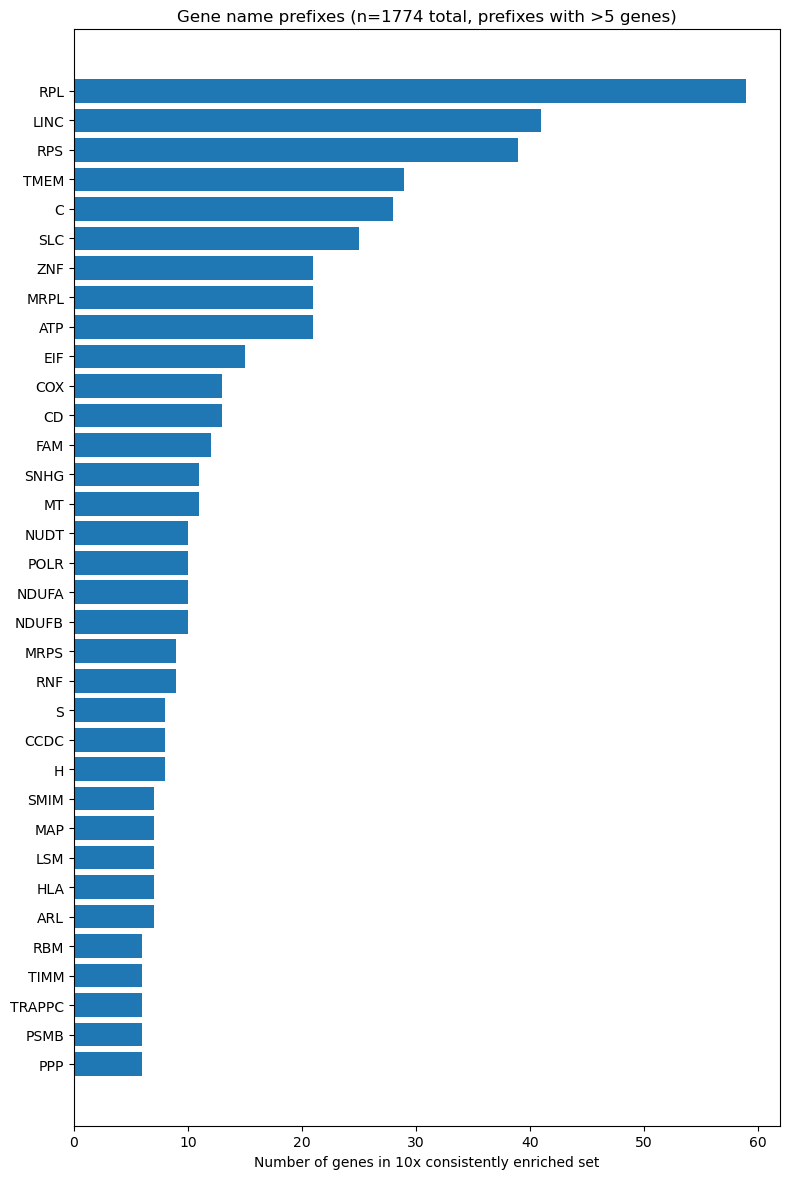

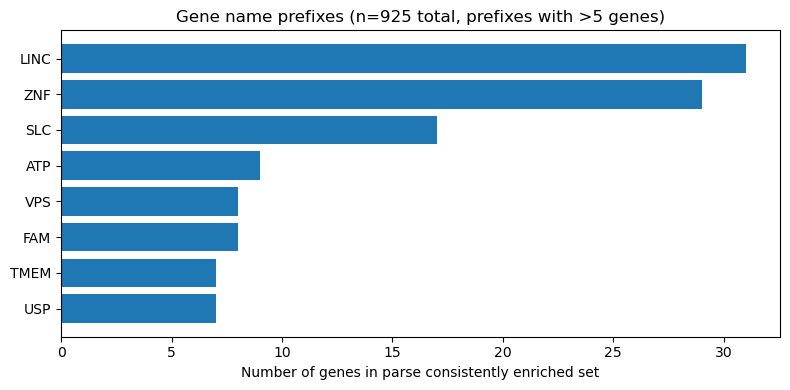

In [14]:
plotting.find_sig_prefixes(results, COMPARING, FDR)